In [1]:

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42
N_SPLITS = 5


In [2]:


TRAIN_PATH = "finnova_train.csv"
TEST_PATH = "finnova_test.csv"

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Could not find {TRAIN_PATH} in: {os.getcwd()}")
if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Could not find {TEST_PATH} in: {os.getcwd()}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
display(train.head())


Train shape: (61835, 31)
Test shape : (20612, 30)


,Txn_ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Txn_Value,Risk_Flag
0,TXN173209,-2.183585,1.892761,-1.142737,-2.436105,1.396925,3.717930,-2.123038,-1.543484,-0.481181,-1.227271,-0.639641,0.417714,-0.185090,1.091807,0.512427,1.322579,-0.646611,0.224825,-0.539427,0.533162,-0.564747,-0.400373,0.350173,0.993206,-0.139172,0.736772,0.113477,0.148835,0.610000,0.000000
1,TXN159667,-1.546892,1.850485,2.176940,3.035659,-1.192864,0.955754,-1.758738,-1.797986,-0.829465,0.030236,-1.401665,-0.662671,-1.566068,0.552593,0.543804,0.202042,0.636967,0.429503,0.827419,0.696027,-1.286355,0.351282,0.008838,0.320438,-0.074777,0.232331,0.071991,0.134451,0.000000,0.000000
2,TXN157896,-1.522655,1.081601,0.182110,0.990186,1.586729,4.474267,-0.949357,1.709973,-0.447918,0.330903,-1.051454,-0.093912,0.028787,-0.124571,-0.317718,1.003747,-0.718222,0.425137,-0.307370,-0.314942,-0.012369,-0.211502,0.074203,0.986499,0.014727,-0.134744,-0.839414,-0.318542,37.050000,0.000000
3,TXN103239,-0.664094,0.425969,2.691272,-1.700911,-0.376081,-0.673883,0.437586,-0.247356,2.562786,-2.037711,0.375823,-2.147507,1.530928,0.916497,-0.034920,-0.398310,0.257443,0.518312,-0.147268,-0.058559,-0.150361,0.098032,-0.369068,0.336507,0.471566,-0.840827,-0.092741,-0.154443,14.530000,0.000000
4,TXN111043,-0.618800,0.601447,1.676447,-0.858323,-0.204625,-0.458810,0.958814,-0.406579,-1.380236,0.426887,-0.129051,0.068019,0.643975,-0.280173,0.199322,-1.595748,-0.315019,0.418210,-2.362076,-0.601486,-0.397481,-0.593460,0.038502,0.321442,-0.458293,-0.860966,-0.238523,-0.083199,65.270000,0.000000


In [3]:

ID_COL = "Txn_ID"
TARGET = "Risk_Flag"

assert ID_COL in train.columns and TARGET in train.columns
assert ID_COL in test.columns and TARGET not in test.columns
assert train[ID_COL].is_unique
assert test[ID_COL].is_unique
assert train[TARGET].isin([0, 1]).all()

feature_columns = [c for c in train.columns if c not in [ID_COL, TARGET]]
test_feature_columns = [c for c in test.columns if c != ID_COL]
assert feature_columns == test_feature_columns, "Train/test feature mismatch"

class_report = pd.DataFrame({
    "Count": train[TARGET].value_counts().sort_index(),
    "Percentage": train[TARGET].value_counts(normalize=True).sort_index() * 100,
})

print("Missing cells — train:", int(train.isna().sum().sum()))
print("Missing cells — test :", int(test.isna().sum().sum()))
print("Number of features   :", len(feature_columns))
display(class_report)


Missing cells — train: 0
Missing cells — test : 0
Number of features   : 29


,Count,Percentage
Risk_Flag,,
0.000000,61708,99.794615
1.000000,127,0.205385


In [4]:

X = train[feature_columns].copy()
y = train[TARGET].astype(int).to_numpy()
X_test = test[feature_columns].copy()
test_ids = test[ID_COL].copy()

# Apply exactly the same transformation to train and test.
if "Txn_Value" in feature_columns:
    X["Txn_Value"] = np.log1p(X["Txn_Value"].clip(lower=0))
    X_test["Txn_Value"] = np.log1p(X_test["Txn_Value"].clip(lower=0))

print("X shape:", X.shape)
print("Positive records:", int(y.sum()))
print("Positive rate:", f"{y.mean():.6%}")


X shape: (61835, 29)
Positive records: 127
Positive rate: 0.205385%


In [5]:

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

oof_probability = np.zeros(len(train), dtype=float)
test_probability = np.zeros(len(test), dtype=float)
feature_importance = np.zeros(len(feature_columns), dtype=float)
fold_scores = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, y), start=1):
    model = ExtraTreesClassifier(
        n_estimators=250,
        criterion="gini",
        max_features="sqrt",
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
    )

    model.fit(X.iloc[train_index], y[train_index])

    valid_probability = model.predict_proba(X.iloc[valid_index])[:, 1]
    oof_probability[valid_index] = valid_probability
    test_probability += model.predict_proba(X_test)[:, 1] / N_SPLITS
    feature_importance += model.feature_importances_ / N_SPLITS

    fold_auc_pr = average_precision_score(y[valid_index], valid_probability)
    fold_scores.append(fold_auc_pr)
    print(f"Fold {fold}: AUC-PR = {fold_auc_pr:.6f}")


Fold 1: AUC-PR = 0.869081


Fold 2: AUC-PR = 0.819979


Fold 3: AUC-PR = 0.926562


Fold 4: AUC-PR = 0.874996


Fold 5: AUC-PR = 0.893660


In [6]:

oof_auc_pr = average_precision_score(y, oof_probability)
oof_roc_auc = roc_auc_score(y, oof_probability)

precision_values, recall_values, thresholds = precision_recall_curve(
    y, oof_probability
)

f1_values = (
    2 * precision_values[:-1] * recall_values[:-1]
    / (precision_values[:-1] + recall_values[:-1] + 1e-12)
)

best_index = int(np.argmax(f1_values))
best_threshold = float(thresholds[best_index])
oof_label = (oof_probability >= best_threshold).astype(int)

metrics = pd.DataFrame({
    "Metric": [
        "Mean fold AUC-PR",
        "OOF AUC-PR",
        "OOF ROC-AUC",
        "Best local threshold",
        "Precision at best threshold",
        "Recall at best threshold",
        "F1 at best threshold",
    ],
    "Value": [
        np.mean(fold_scores),
        oof_auc_pr,
        oof_roc_auc,
        best_threshold,
        precision_score(y, oof_label, zero_division=0),
        recall_score(y, oof_label, zero_division=0),
        f1_score(y, oof_label, zero_division=0),
    ],
})

display(metrics)
print(classification_report(y, oof_label, digits=4, zero_division=0))


,Metric,Value
0,Mean fold AUC-PR,0.876856
1,OOF AUC-PR,0.869428
2,OOF ROC-AUC,0.958048
3,Best local threshold,0.224000
4,Precision at best threshold,0.881890
5,Recall at best threshold,0.881890
6,F1 at best threshold,0.881890


              precision    recall  f1-score   support

           0     0.9998    0.9998    0.9998     61708
           1     0.8819    0.8819    0.8819       127

    accuracy                         0.9995     61835
   macro avg     0.9408    0.9408    0.9408     61835
weighted avg     0.9995    0.9995    0.9995     61835



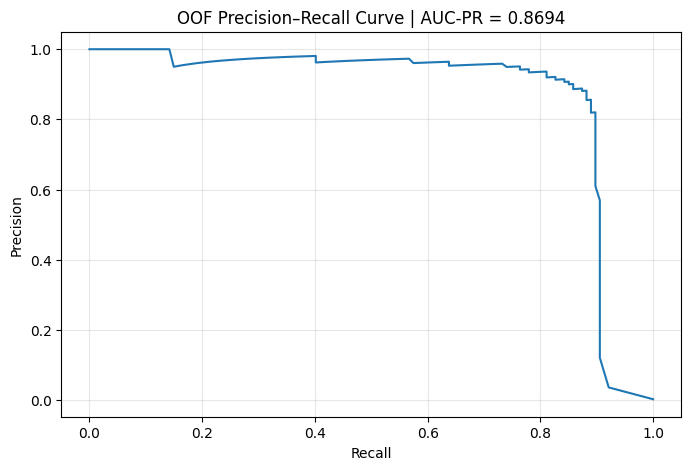

In [7]:

plt.figure(figsize=(8, 5))
plt.plot(recall_values, precision_values)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"OOF Precision–Recall Curve | AUC-PR = {oof_auc_pr:.4f}")
plt.grid(alpha=0.3)
plt.show()


,Feature,Importance
13,Feature_14,0.147798
11,Feature_12,0.119592
16,Feature_17,0.104427
10,Feature_11,0.077528
15,Feature_16,0.076183
9,Feature_10,0.067917
3,Feature_4,0.063069
2,Feature_3,0.057618
17,Feature_18,0.044677
28,Txn_Value,0.026063


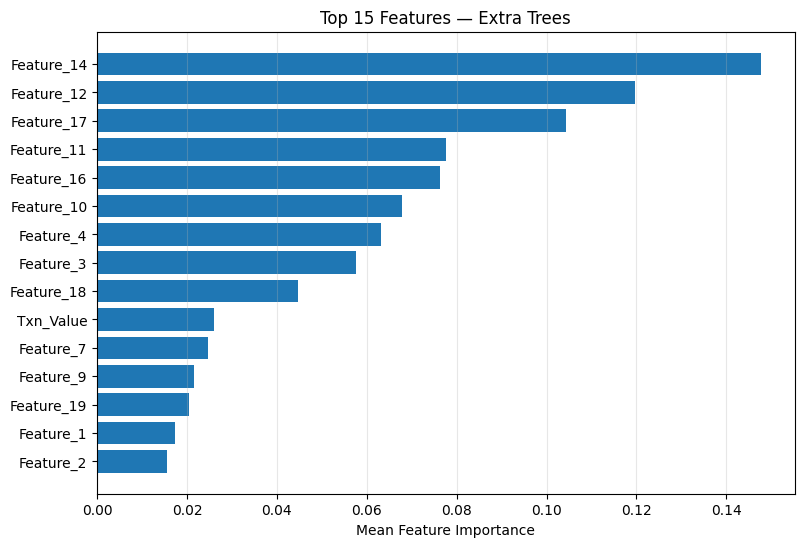

In [8]:

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": feature_importance,
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(9, 6))
top_importance = importance_df.head(15).sort_values("Importance")
plt.barh(top_importance["Feature"], top_importance["Importance"])
plt.xlabel("Mean Feature Importance")
plt.title("Top 15 Features — Extra Trees")
plt.grid(axis="x", alpha=0.3)
plt.show()


In [9]:

submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: test_probability,
})

# Final safety checks
assert len(submission) == len(test)
assert submission[ID_COL].is_unique
assert not submission.isna().any().any()
assert submission[TARGET].between(0, 1).all()

submission.to_csv(
    "submission.csv",
    index=False,
    float_format="%.10f",
)

print("Saved submission.csv")
print("Submission shape:", submission.shape)
print("Probability range:", submission[TARGET].min(), "to", submission[TARGET].max())
print("Mean probability:", submission[TARGET].mean())
display(submission.head(10))


Saved submission.csv
Submission shape: (20612, 2)
Probability range: 0.0 to 0.9848
Mean probability: 0.001790607413157384


,Txn_ID,Risk_Flag
0,TXN178145,0.003200
1,TXN173470,0.000000
2,TXN140553,0.000000
3,TXN175362,0.000000
4,TXN169993,0.000800
5,TXN134722,0.000000
6,TXN102647,0.000000
7,TXN112339,0.000000
8,TXN159443,0.000000
9,TXN119639,0.000000


In [10]:


submission_check = pd.read_csv("submission.csv")
print(submission_check.shape)
print(submission_check.isna().sum())
display(submission_check.head())


(20612, 2)
Txn_ID       0
Risk_Flag    0
dtype: int64


,Txn_ID,Risk_Flag
0,TXN178145,0.003200
1,TXN173470,0.000000
2,TXN140553,0.000000
3,TXN175362,0.000000
4,TXN169993,0.000800
